# Graduation Lab (Week 6)
## Instructions:

Let's build a kNN model using the college completion data from last week. 
The data is messy and you have a degrees of freedom problem, as in, we have too many features.  

You've done most of the hard work already, so you should be ready to move forward with building your model. 

1. Use the question/target variable you submitted from last week and build a model to answer the question you created for this dataset. 

2. Build and optimize a kNN model to predict your target variable. Meaning use the tune set to select the correct k value. 

3. Experiment with the threshold function, what happens at higher and lower thresholds. Document what you see in comments. 

4. Evaluate the results using the confusion matrix (at the default threshold). Then talk through your question, summarize what concerns or positive elements do you have about the model? 


## Question and IBM:

**Question** Is there a correlation between grad_100 and the whether a college can be considered "high_award"?

**IBM** `high_award` = Whether or not the institution has a high award status (1 = high award status, 0 = low award status). `high_award` is determined by whether the institution's awards per state value is above the Q3 value of awards per 100 graduates across all institutions.


In [76]:
import pandas as pd
import numpy as np
import seaborn as sns
import random
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay , classification_report, confusion_matrix
from matplotlib import pyplot as plt

In [77]:
# Data Preparation and Cleaning for College Completion Dataset
COLLEGE = pd.read_csv("cc_institution_details.csv")
COLLEGE.info()

<class 'pandas.DataFrame'>
RangeIndex: 3798 entries, 0 to 3797
Data columns (total 63 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   index                                 3798 non-null   int64  
 1   unitid                                3798 non-null   int64  
 2   chronname                             3798 non-null   str    
 3   city                                  3798 non-null   str    
 4   state                                 3798 non-null   str    
 5   level                                 3798 non-null   str    
 6   control                               3798 non-null   str    
 7   basic                                 3798 non-null   str    
 8   hbcu                                  94 non-null     str    
 9   flagship                              50 non-null     str    
 10  long_x                                3798 non-null   float64
 11  lat_y                       

In [78]:
# Turning "chronname" into type object
COLLEGE["chronname"] = COLLEGE["chronname"].astype(object)

In [79]:
# Turning necessary variables into categorical variables
cat_cols = ["state", "level", "control"]

for col in cat_cols:
    COLLEGE[col] = COLLEGE[col].astype("category")

COLLEGE.info()

<class 'pandas.DataFrame'>
RangeIndex: 3798 entries, 0 to 3797
Data columns (total 63 columns):
 #   Column                                Non-Null Count  Dtype   
---  ------                                --------------  -----   
 0   index                                 3798 non-null   int64   
 1   unitid                                3798 non-null   int64   
 2   chronname                             3798 non-null   object  
 3   city                                  3798 non-null   str     
 4   state                                 3798 non-null   category
 5   level                                 3798 non-null   category
 6   control                               3798 non-null   category
 7   basic                                 3798 non-null   str     
 8   hbcu                                  94 non-null     str     
 9   flagship                              50 non-null     str     
 10  long_x                                3798 non-null   float64 
 11  lat_y          

In [80]:
# Turning Boolean columns into 0s and 1s
bool_cols = ["flagship"]

for col in bool_cols:
    if col in COLLEGE.columns:
        COLLEGE[col] = (COLLEGE[col] == "X").astype(int)

In [81]:
# Create the "high_threshold" variable/column
high_threshold = COLLEGE["awards_per_state_value"].quantile(0.75)

COLLEGE["high_award"] = (
    COLLEGE["awards_per_state_value"] > high_threshold
).astype(int)

In [82]:
# One-hot encoding categorical variables
one_hot_columns = ["level", "control", "high_award"]

cols_to_encode = [c for c in one_hot_columns if c in COLLEGE.columns]

if cols_to_encode:
    COLLEGE = pd.get_dummies(COLLEGE, columns=cols_to_encode)

In [83]:
# Standardizing and scaling numerical columns
columns = [
    "aid_percentile",
    "aid_value",
    "endow_value",
    "endow_percentile",
    "grad_100_value",
    "grad_100_percentile",
    "grad_150_value",
    "grad_150_percentile",
    "exp_award_percentile",
    "exp_award_value",
    "exp_award_state_value",
    "exp_award_natl_value",
    "ft_pct",
    "fte_value",
    "fte_percentile",
    "med_sat_value",
    "med_sat_percentile",
    "student_count",
    "awards_per_value",
    "awards_per_state_value",
    "awards_per_natl_value"
]

scaler = MinMaxScaler()

for col in columns:
    if col in columns:
        COLLEGE[[col]] = scaler.fit_transform(COLLEGE[[col]])


In [84]:
# Dropping unnecessary columns
cols_by_name = [
    "site",
    "long_x",
    "lat_y",
    "med_sat_percentile",
    "med_sat_value",
    "endow_value",
    "basic",
    "endow_percentile",
    "unitid",
    "city",
    "hbcu",
    "state",
    "awards_per_value",
    "awards_per_state_value",
    "awards_per_natl_value",
    "index",
    "chronname"
]

cols_by_index = COLLEGE.columns[34:63]

cols_to_drop = [c for c in cols_by_name + list(cols_by_index) if c in COLLEGE.columns]

if cols_to_drop:
    COLLEGE_dt = COLLEGE.drop(columns=cols_to_drop)


In [85]:
COLLEGE_dt.info()

<class 'pandas.DataFrame'>
RangeIndex: 3798 entries, 0 to 3797
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   flagship                        3798 non-null   int64  
 1   student_count                   3798 non-null   float64
 2   exp_award_value                 3798 non-null   float64
 3   exp_award_state_value           3798 non-null   float64
 4   exp_award_natl_value            3798 non-null   float64
 5   exp_award_percentile            3798 non-null   float64
 6   ft_pct                          3794 non-null   float64
 7   fte_value                       3798 non-null   float64
 8   fte_percentile                  3798 non-null   float64
 9   aid_value                       3797 non-null   float64
 10  aid_percentile                  3797 non-null   float64
 11  grad_100_value                  3467 non-null   float64
 12  grad_100_percentile             3467 non-null

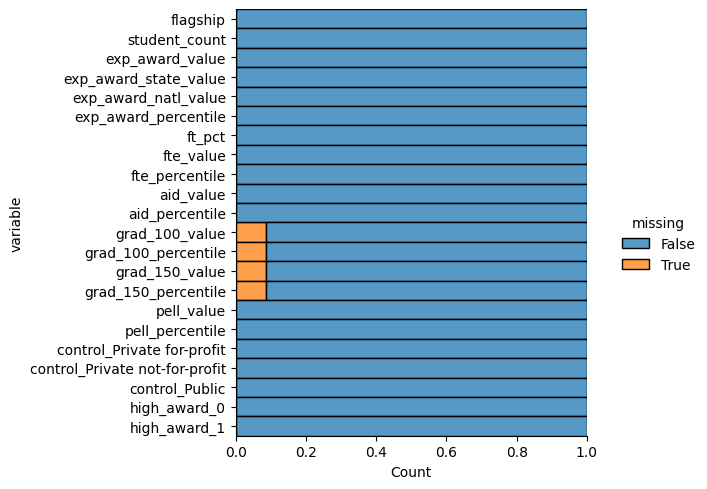

In [86]:
sns.displot(
    data=COLLEGE_dt.isna().melt(value_name="missing"),
    y="variable",
    hue="missing",
    multiple="fill",
    aspect=1.25
)

In [87]:
# Drop all rows with missing data 
COLLEGE_dt.dropna(axis = 0, how = 'any', inplace = True)

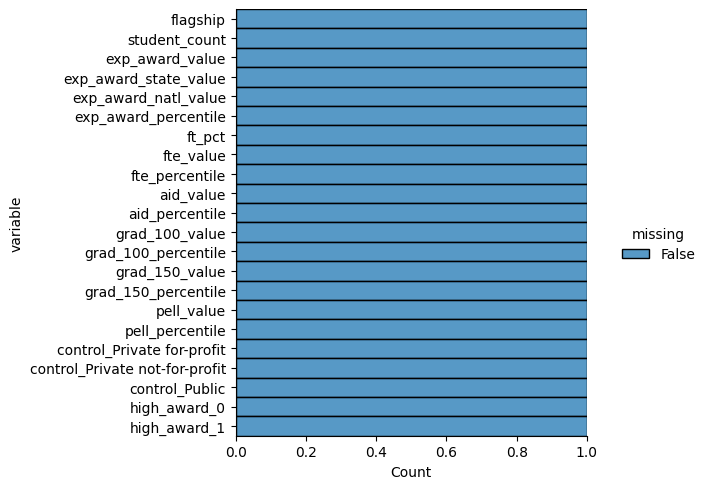

In [88]:
sns.displot(
    data=COLLEGE_dt.isna().melt(value_name="missing"),
    y="variable",
    hue="missing",
    multiple="fill",
    aspect=1.25
)

In [89]:
COLLEGE_dt.describe()

,flagship,student_count,exp_award_value,exp_award_state_value,exp_award_natl_value,exp_award_percentile,ft_pct,fte_value,fte_percentile,aid_value,aid_percentile,grad_100_value,grad_100_percentile,grad_150_value,grad_150_percentile,pell_value,pell_percentile
count,3466.000000,3466.000000,3466.000000,3466.000000,3466.000000,3466.000000,3466.000000,3466.000000,3466.000000,3466.000000,3466.000000,3466.000000,3466.000000,3466.000000,3466.000000,3466.000000,3466.000000
mean,0.014426,0.027325,0.012652,0.280121,0.477144,0.512043,0.704676,0.030457,0.511463,0.192649,0.512969,0.283533,0.467175,0.424005,0.488549,46.355597,49.189556
std,0.119255,0.043680,0.021155,0.191321,0.393944,0.287838,0.259162,0.048095,0.287836,0.159907,0.286137,0.233069,0.305393,0.234605,0.294829,19.671462,28.807138
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.003786,0.006209,0.131251,0.168790,0.270000,0.480249,0.005414,0.270000,0.091375,0.270000,0.090000,0.200000,0.227000,0.230000,31.825000,24.000000
50%,0.000000,0.011445,0.009815,0.237985,0.181568,0.520000,0.773909,0.013452,0.520000,0.122959,0.520000,0.225000,0.460000,0.411000,0.490000,43.400000,49.000000
75%,0.000000,0.032204,0.014942,0.382101,1.000000,0.760000,0.937630,0.034978,0.760000,0.240899,0.760000,0.436000,0.730000,0.602000,0.740000,59.775000,74.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,100.000000,100.000000


In [90]:
COLLEGE_dt.head()

,flagship,student_count,exp_award_value,exp_award_state_value,exp_award_natl_value,exp_award_percentile,ft_pct,fte_value,fte_percentile,aid_value,...,grad_100_percentile,grad_150_value,grad_150_percentile,pell_value,pell_percentile,control_Private for-profit,control_Private not-for-profit,control_Public,high_award_0,high_award_1
0,0,0.023677,0.019941,0.359141,0.541284,0.90,0.935551,0.030646,0.33,0.165867,...,0.15,0.291,0.14,71.2,98.0,False,False,True,True,False
1,0,0.067476,0.025851,0.359141,0.541284,0.97,0.716216,0.079120,0.67,0.140338,...,0.67,0.535,0.66,35.1,39.0,False,False,True,True,False
2,0,0.001758,0.011059,0.452754,1.000000,0.30,0.612266,0.002065,0.12,0.054401,...,0.00,0.667,0.72,68.4,91.0,False,True,False,True,False
3,0,0.033347,0.012196,0.359141,0.541284,0.61,0.733888,0.039303,0.40,0.153878,...,0.34,0.484,0.54,32.8,32.0,False,False,True,True,False
4,0,0.031348,0.025067,0.359141,0.541284,0.96,0.906445,0.039580,0.41,0.168629,...,0.11,0.252,0.09,82.7,100.0,False,False,True,True,False


In [91]:
# Calculating prevalence
total_rows = len(COLLEGE_dt)
prevalence = COLLEGE_dt["high_award_1"].sum() / total_rows
print(f"Prevalence of High Award Status: {prevalence:.2f}")

Prevalence of High Award Status: 0.22


In [92]:
COLLEGE_dt.info()

<class 'pandas.DataFrame'>
Index: 3466 entries, 0 to 3797
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   flagship                        3466 non-null   int64  
 1   student_count                   3466 non-null   float64
 2   exp_award_value                 3466 non-null   float64
 3   exp_award_state_value           3466 non-null   float64
 4   exp_award_natl_value            3466 non-null   float64
 5   exp_award_percentile            3466 non-null   float64
 6   ft_pct                          3466 non-null   float64
 7   fte_value                       3466 non-null   float64
 8   fte_percentile                  3466 non-null   float64
 9   aid_value                       3466 non-null   float64
 10  aid_percentile                  3466 non-null   float64
 11  grad_100_value                  3466 non-null   float64
 12  grad_100_percentile             3466 non-null   fl

In [93]:
# Splitting the dataset into Train, Test, and Tune sets
Train, Test = train_test_split(COLLEGE_dt, train_size=0.4, stratify=COLLEGE_dt["high_award_1"])


In [94]:
# Splitting the dataset into Train, Test, and Tune sets
Test, Val = train_test_split(Test, test_size=0.5, stratify=Test["high_award_1"])

In [ ]:
random.seed(1984)   # kNN is a random algorithm, so we use `random.seed(x)` to make results repeatable

X_train = Train.drop(['high_award_1'], axis=1).values
y_train = Train['high_award_1'].values

neigh = KNeighborsClassifier(n_neighbors=3)
neigh.fit(X_train, y_train)

# now, we check the model's accuracy on the test data:

X_test = Test.drop(['high_award_1'], axis=1).values
y_test = Test['high_award_1'].values

neigh.score(X_test, y_test)

# now, we test the accuracy on our validation data.

X_val = Val.drop(['high_award_1'], axis=1).values
y_val = Val['high_award_1'].values

neigh.score(X_val, y_val)

ConfusionMatrixDisplay.from_estimator(
    neigh,
    X_val,
    y_val,
    cmap='Purples'
)

plt.show()

0.9153846153846154

In [96]:
# now, we check the model's accuracy on the test data:

X_test = Test.drop(['high_award_1'], axis=1).values
y_test = Test['high_award_1'].values

neigh.score(X_test, y_test)

0.9115384615384615

In [97]:
# now, we test the accuracy on our validation data.

X_val = Val.drop(['high_award_1'], axis=1).values
y_val = Val['high_award_1'].values

neigh.score(X_val, y_val)

0.9240384615384616

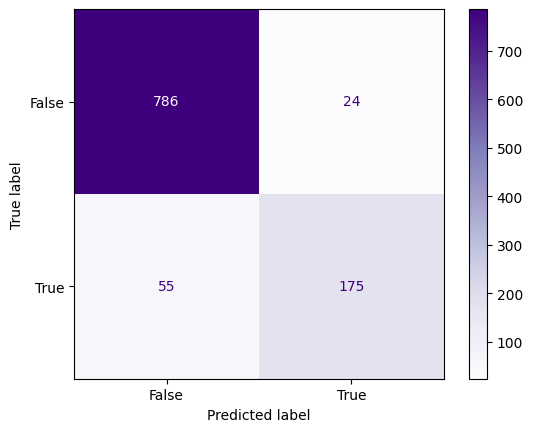

In [98]:
ConfusionMatrixDisplay.from_estimator(
    neigh,
    X_val,
    y_val,
    cmap='Purples'
)

plt.show()

In [99]:
y_val_pred = neigh.predict(X_val)
print(classification_report(y_val_pred, y_val))

              precision    recall  f1-score   support

       False       0.97      0.93      0.95       841
        True       0.76      0.88      0.82       199

    accuracy                           0.92      1040
   macro avg       0.87      0.91      0.88      1040
weighted avg       0.93      0.92      0.93      1040



In [ ]:
# Function to determine the "k" with the best accuracy
def chooseK(k, X_train, y_train, X_test, y_test):
    random.seed(1)
    print("calculating... ", k, "k")    # I'll include this so you can see the progress of the function as it runs
    class_knn = KNeighborsClassifier(n_neighbors=k)
    class_knn.fit(X_train, y_train)
    
    # calculate accuracy
    accu = class_knn.score(X_test, y_test)
    return accu

test = pd.DataFrame({'k':list(range(1,22,2)), 
                     'accu':[chooseK(x, X_train, y_train, X_test, y_test) for x in list(range(1, 22, 2))]})

test = test.sort_values(by=['accu'], ascending=False)
test

In [101]:
test = pd.DataFrame({'k':list(range(1,22,2)), 
                     'accu':[chooseK(x, X_train, y_train, X_test, y_test) for x in list(range(1, 22, 2))]})

test = test.sort_values(by=['accu'], ascending=False)
test

calculating...  1 k
calculating...  3 k
calculating...  5 k
calculating...  7 k
calculating...  9 k
calculating...  11 k
calculating...  13 k
calculating...  15 k
calculating...  17 k
calculating...  19 k
calculating...  21 k


,k,accu
0,1,0.911538
1,3,0.896154
2,5,0.877885
3,7,0.872115
5,11,0.866346
6,13,0.862500
4,9,0.861538
7,15,0.857692
8,17,0.857692
9,19,0.857692


k = 1 is going to be the best.

In [102]:
# we want to make a table containing: probability, expected, and actual values

test_probs = neigh.predict_proba(X_test)
test_preds = neigh.predict(X_test)

In [103]:
# convert probabilities to pd df
test_probabilities = pd.DataFrame(test_probs, columns = ['not_high_award_prob', 'high_award_prob'])
test_probabilities

,not_high_award_prob,high_award_prob
0,1.0,0.0
1,1.0,0.0
2,0.0,1.0
3,1.0,0.0
4,1.0,0.0
...,...,...
1035,1.0,0.0
1036,1.0,0.0
1037,1.0,0.0
1038,0.0,1.0


In [104]:
final_model = pd.DataFrame({'actual_class': y_test.tolist(),
                           'pred_class': test_preds.tolist(),
                           'pred_prob': [test_probabilities['high_award_prob'][i] if test_preds[i]==1 else test_probabilities['not_high_award_prob'][i] for i in range(len(test_preds))]})

In [105]:
final_model.head()

,actual_class,pred_class,pred_prob
0,False,False,1.0
1,False,False,1.0
2,False,True,1.0
3,False,False,1.0
4,False,False,1.0


In [106]:
# add a column about the probability the observation is in the positive class
final_model['pos_pred'] = [final_model.pred_prob[i] if final_model.pred_class[i]==1 else 1-final_model.pred_prob[i] for i in range(len(final_model.pred_class))]

In [107]:
final_model.head()

,actual_class,pred_class,pred_prob,pos_pred
0,False,False,1.0,0.0
1,False,False,1.0,0.0
2,False,True,1.0,1.0
3,False,False,1.0,0.0
4,False,False,1.0,0.0


In [108]:
# convert classes to categories
final_model.actual_class = final_model.actual_class.astype('category')
final_model.pred_class = final_model.pred_class.astype('category')

final_model.head()

,actual_class,pred_class,pred_prob,pos_pred
0,False,False,1.0,0.0
1,False,False,1.0,0.0
2,False,True,1.0,1.0
3,False,False,1.0,0.0
4,False,False,1.0,0.0


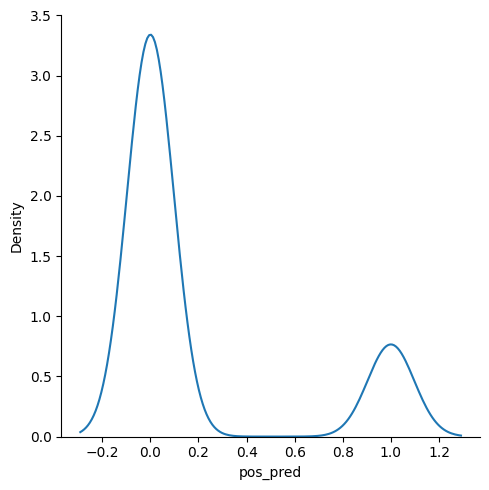

In [109]:
sns.displot(final_model, x="pos_pred", kind="kde")

In [110]:
final_model.pos_pred.value_counts()

pos_pred
0.0    846
1.0    194
Name: count, dtype: int64

In [111]:
# Function to adjust threshold for positive class

def adjust_thres(x, y, z):
    """
    x=pred_probabilities
    y=threshold
    z=tune_outcome
    """
    thres = pd.DataFrame({'new_preds': [1 if i > y else 0 for i in x]})
    thres.new_preds = thres.new_preds.astype('category')
    con_mat = confusion_matrix(z, thres)  
    print(con_mat)

In [112]:
# original model
confusion_matrix(final_model.actual_class, final_model.pred_class)

array([[782,  28],
       [ 64, 166]])

In [113]:
adjust_thres(final_model.pos_pred, .8, final_model.actual_class)   # raise threshold 

[[782  28]
 [ 64 166]]


In [114]:
adjust_thres(final_model.pos_pred, .4, final_model.actual_class)   # lower threshold

[[782  28]
 [ 64 166]]


In [115]:
adjust_thres(final_model.pos_pred, .2, final_model.actual_class)  

[[782  28]
 [ 64 166]]
